--- MATRIZ PRONTA PARA MINERAÇÃO (K-MEANS/ASSOCIACAO) ---
      Faixa_Etaria    Genero Media_Moradores
0      Até 17 anos    Homens            3.49
1     18 a 24 anos    Homens            2.62
2     25 a 39 anos    Homens            2.93
3     40 a 59 anos    Homens            2.97
4  60 anos ou mais    Homens            2.44
5      Até 17 anos  Mulheres            3.56
6     18 a 24 anos  Mulheres            2.84
7     25 a 39 anos  Mulheres            3.24
8     40 a 59 anos  Mulheres            2.94
9  60 anos ou mais  Mulheres            2.17


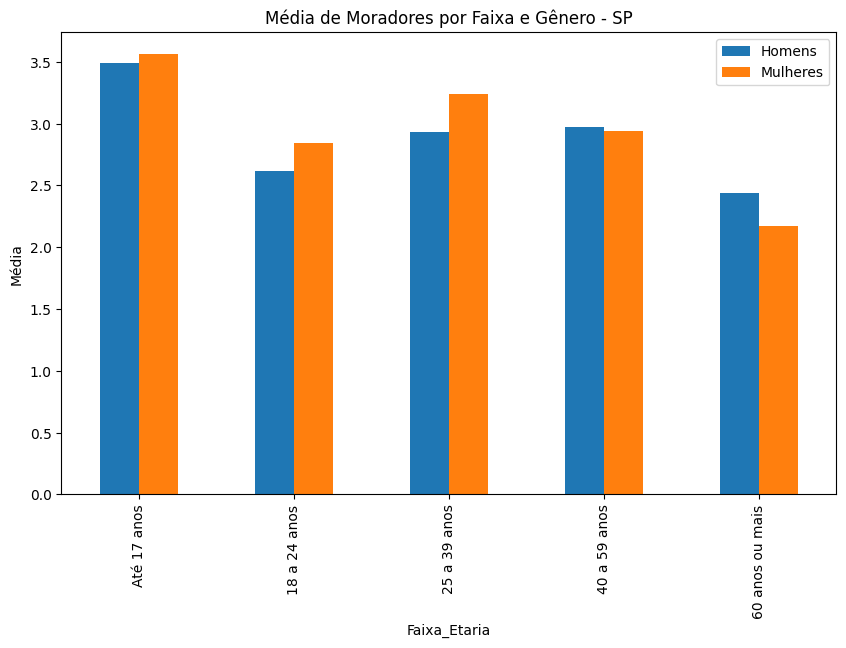

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CARREGAMENTO DOS DADOS (Focado no Estado de SP)
# Lendo a planilha de idades
df_ida = pd.read_excel("moradores por idade.xlsx", header=None)

# 2. PRÉ-PROCESSAMENTO 
# Vamos separar Homens e Mulheres para termos mais dados para o agrupamento
# Linha 3 = Cabeçalho, Linha 4 = Valores de SP
faixas = ['Até 17 anos', '18 a 24 anos', '25 a 39 anos', '40 a 59 anos', '60 anos ou mais']

# Extraindo valores (Colunas 1 a 5 para Homens, 6 a 10 para Mulheres)
homens = df_ida.iloc[4, 1:6].values
mulheres = df_ida.iloc[4, 6:11].values

# Criando a matriz integrada para mineração
df_analise = pd.DataFrame({
    'Faixa_Etaria': faixas,
    'Homens': homens,
    'Mulheres': mulheres
})

# Ajustando o formato para mineração
df_minercao = df_analise.melt(id_vars='Faixa_Etaria', var_name='Genero', value_name='Media_Moradores')

print("--- MATRIZ PRONTA PARA MINERAÇÃO (K-MEANS/ASSOCIACAO) ---")
print(df_minercao.head(10))

# 3. VISUALIZAÇÃO - Gráfico de barras para comparar as médias por faixa etária e gênero
df_analise.plot(kind='bar', x='Faixa_Etaria', figsize=(10, 6), title='Média de Moradores por Faixa e Gênero - SP')
plt.ylabel('Média')
plt.show()

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Preparando os dados numéricos
X = df_minercao[['Media_Moradores']]

# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicando K-Means (definindo 3 grupos/clusters como exemplo)
kmeans = KMeans(n_clusters=3, random_state=42)
df_minercao['Cluster'] = kmeans.fit_predict(X_scaled)

print("--- RESULTADO DO AGRUPAMENTO (K-MEANS) ---")
print(df_minercao)

--- RESULTADO DO AGRUPAMENTO (K-MEANS) ---
      Faixa_Etaria    Genero Media_Moradores  Cluster
0      Até 17 anos    Homens            3.49        2
1     18 a 24 anos    Homens            2.62        0
2     25 a 39 anos    Homens            2.93        0
3     40 a 59 anos    Homens            2.97        0
4  60 anos ou mais    Homens            2.44        1
5      Até 17 anos  Mulheres            3.56        2
6     18 a 24 anos  Mulheres            2.84        0
7     25 a 39 anos  Mulheres            3.24        2
8     40 a 59 anos  Mulheres            2.94        0
9  60 anos ou mais  Mulheres            2.17        1


C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [3]:
# Criando categorias para facilitar a associação
def categorizar(valor):
    if valor < 2.5: return 'Baixa'
    elif valor < 3.0: return 'Media'
    else: return 'Alta'

df_minercao['Categoria_Media'] = df_minercao['Media_Moradores'].apply(categorizar)


# Associar: {Genero: Mulher, Categoria_Media: Alta} -> {Faixa_Etaria: Até 17 anos}
print(df_minercao[['Faixa_Etaria', 'Genero', 'Categoria_Media']].head())

      Faixa_Etaria  Genero Categoria_Media
0      Até 17 anos  Homens            Alta
1     18 a 24 anos  Homens           Media
2     25 a 39 anos  Homens           Media
3     40 a 59 anos  Homens           Media
4  60 anos ou mais  Homens           Baixa


In [4]:

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Criar uma lista de transações baseada na nossa matriz df_minercao
# Cada linha vira uma lista de atributos
transactions = []
for index, row in df_minercao.iterrows():
    # Criamos "itens" como strings combinando a coluna e o valor
    transactions.append([
        f"Faixa_{row['Faixa_Etaria']}", 
        f"Genero_{row['Genero']}", 
        f"Media_{row['Categoria_Media']}"
    ])

# Codificar os dados
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# 2. Aplicar o Algoritmo Apriori
# min_support define a frequência mínima que um conjunto de itens deve aparecer
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

# 3. Gerar as Regras de Associação
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

print("--- REGRAS DE ASSOCIAÇÃO ENCONTRADAS ---")
# Filtramos para mostrar as colunas mais importantes para o relatório
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

--- REGRAS DE ASSOCIAÇÃO ENCONTRADAS ---
                             antecedents                    consequents  \
0                   (Faixa_18 a 24 anos)                (Genero_Homens)   
1                   (Faixa_18 a 24 anos)              (Genero_Mulheres)   
2                   (Faixa_18 a 24 anos)                  (Media_Media)   
3                   (Faixa_25 a 39 anos)                (Genero_Homens)   
4                   (Faixa_25 a 39 anos)              (Genero_Mulheres)   
..                                   ...                            ...   
57                   (Faixa_Até 17 anos)    (Genero_Homens, Media_Alta)   
58  (Genero_Mulheres, Faixa_Até 17 anos)                   (Media_Alta)   
59         (Genero_Mulheres, Media_Alta)            (Faixa_Até 17 anos)   
60       (Faixa_Até 17 anos, Media_Alta)              (Genero_Mulheres)   
61                   (Faixa_Até 17 anos)  (Genero_Mulheres, Media_Alta)   

    support  confidence      lift  
0       0.1         0.

C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_

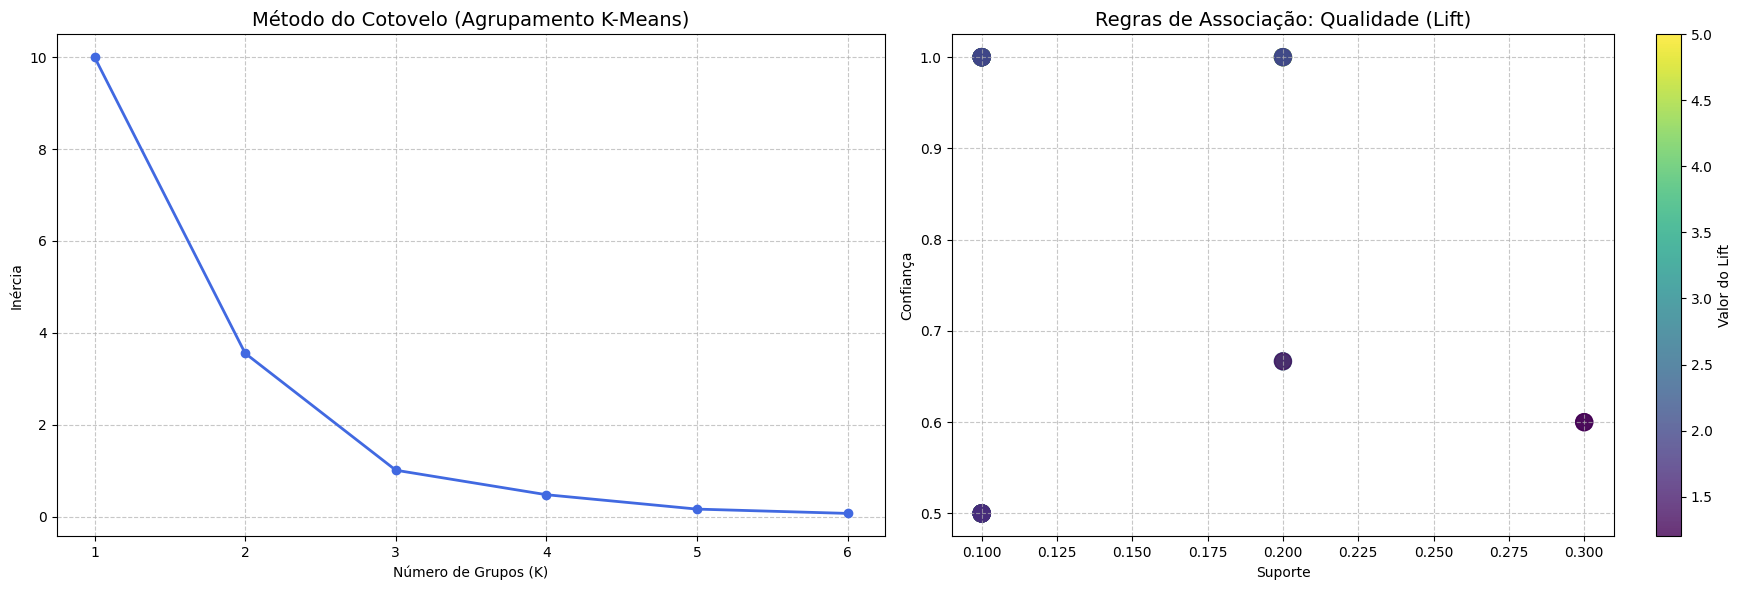

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. RECALCULANDO O COTOVELO (Para garantir que a variável exista)
X = df_minercao[['Media_Moradores']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
for k in range(1, 7):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(kmeans.inertia_)

# 2. PREPARANDO AS REGRAS PARA O SCATTER (Filtro de qualidade)
# Filtrando regras com Lift > 1 para maior relevância
top_rules = rules[rules['lift'] > 1].sort_values(by='lift', ascending=False)

# 3. GERANDO O PAINEL LADO A LADO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Método do Cotovelo
ax1.plot(range(1, 7), inertias, marker='o', color='royalblue', linewidth=2)
ax1.set_title('Método do Cotovelo (Agrupamento K-Means)', fontsize=14)
ax1.set_xlabel('Número de Grupos (K)')
ax1.set_ylabel('Inércia')
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Qualidade das Regras (Scatter Plot)
sc = ax2.scatter(top_rules['support'], top_rules['confidence'], 
                 c=top_rules['lift'], cmap='viridis', s=150, alpha=0.8)
ax2.set_title('Regras de Associação: Qualidade (Lift)', fontsize=14)
ax2.set_xlabel('Suporte')
ax2.set_ylabel('Confiança')
plt.colorbar(sc, label='Valor do Lift')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

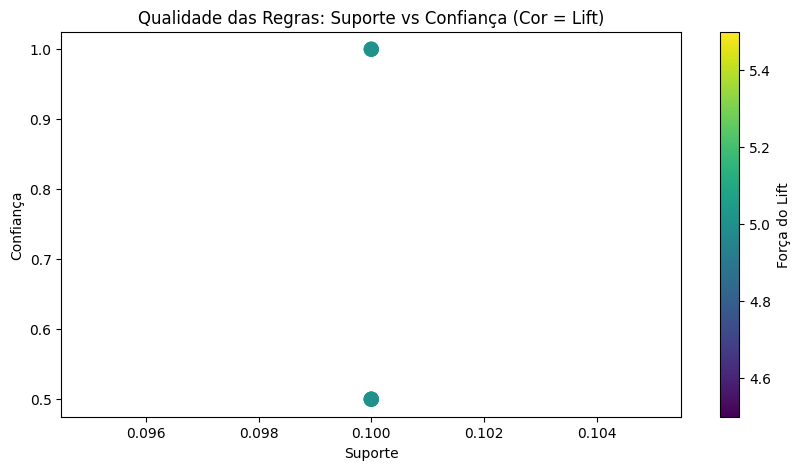

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos apenas as regras com Lift > 1 (regras fortes)
top_rules = rules[rules['lift'] > 1].sort_values(by='lift', ascending=False).head(5)

# Visualização: Gráfico de Dispersão (Lift vs Confiança)
plt.figure(figsize=(10, 5))
plt.scatter(top_rules['support'], top_rules['confidence'], c=top_rules['lift'], cmap='viridis', s=100)
plt.colorbar(label='Força do Lift')
plt.xlabel('Suporte')
plt.ylabel('Confiança')
plt.title('Qualidade das Regras: Suporte vs Confiança (Cor = Lift)')
plt.show()

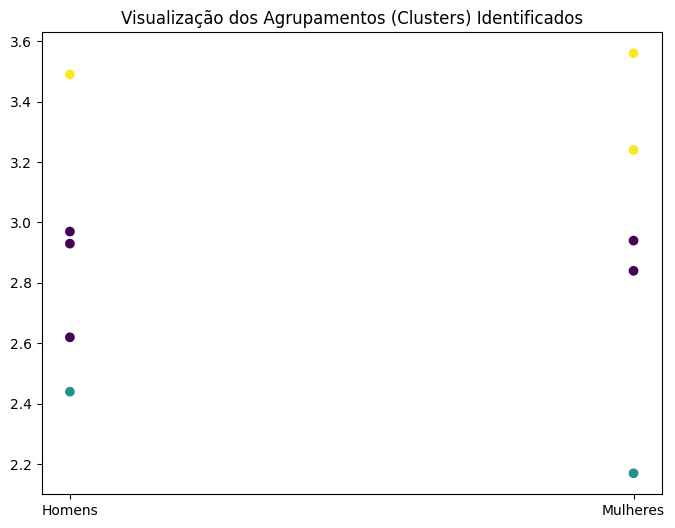

In [7]:

plt.figure(figsize=(8, 6))
plt.scatter(df_minercao['Genero'], df_minercao['Media_Moradores'], c=df_minercao['Cluster'], cmap='viridis')
plt.title('Visualização dos Agrupamentos (Clusters) Identificados')
plt.show()